In [ ]:
library(dplyr)

# Load data
mat <- read.csv("data/content/student-mat.csv", sep=";")
por <- read.csv("data/content/student-por.csv", sep=";")

# Add subject column before merging
mat$subject <- "math"
por$subject <- "portuguese"

all_students <- bind_rows(mat, por)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
# Remove duplicates
all_students <- all_students[!duplicated(all_students), ]

# Mode function
getmode <- function(v) {
  uniqv <- unique(v)
  uniqv[which.max(tabulate(match(v, uniqv)))]
}

# Fill missing values
for(col in names(all_students)) {
  if(is.numeric(all_students[[col]])) {
    all_students[[col]][is.na(all_students[[col]])] <- median(all_students[[col]], na.rm = TRUE)
  } else {
    all_students[[col]][is.na(all_students[[col]])] <- getmode(all_students[[col]])
  }
}

In [3]:
# Convert categorical columns
categorical_cols <- c("school","sex","address","famsize","Pstatus",
                      "Mjob","Fjob","reason","guardian","schoolsup",
                      "famsup","paid","activities","nursery","higher",
                      "internet","romantic")

all_students[categorical_cols] <- lapply(all_students[categorical_cols], as.factor)

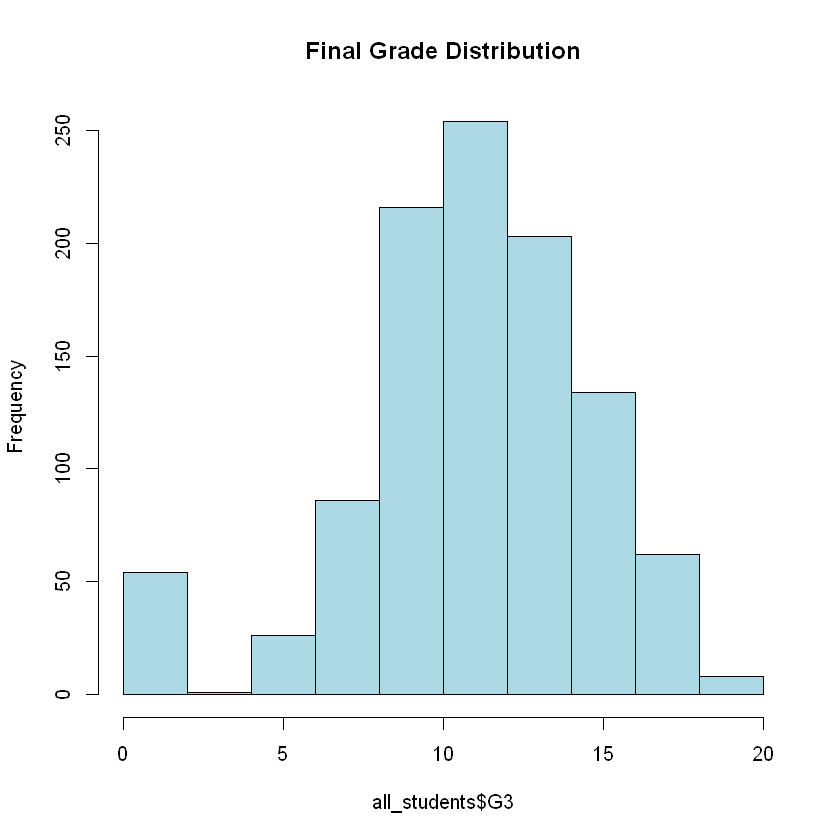

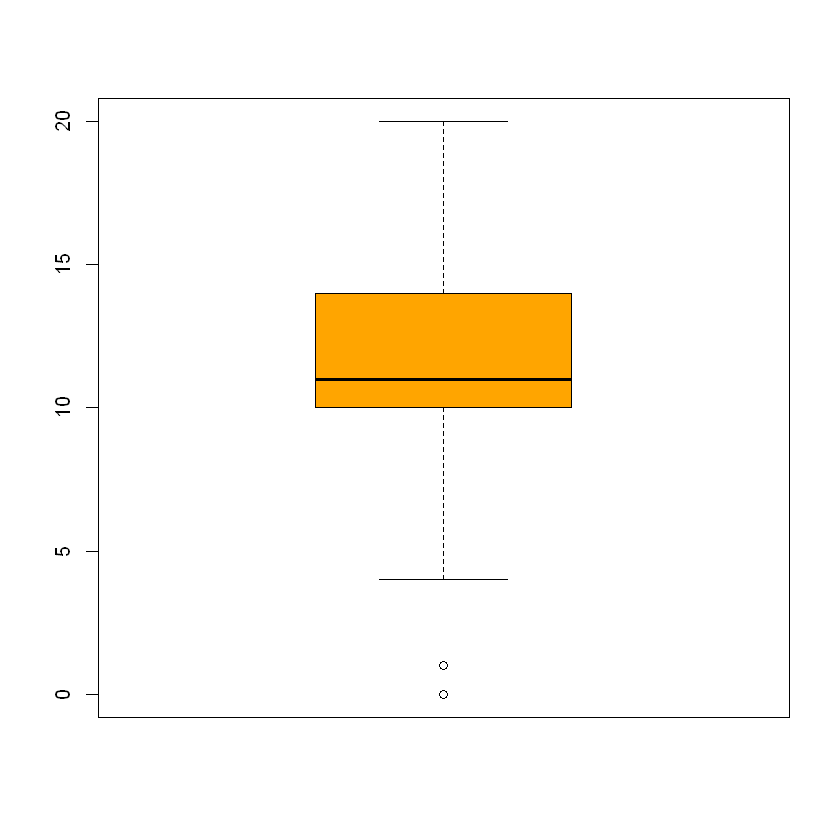

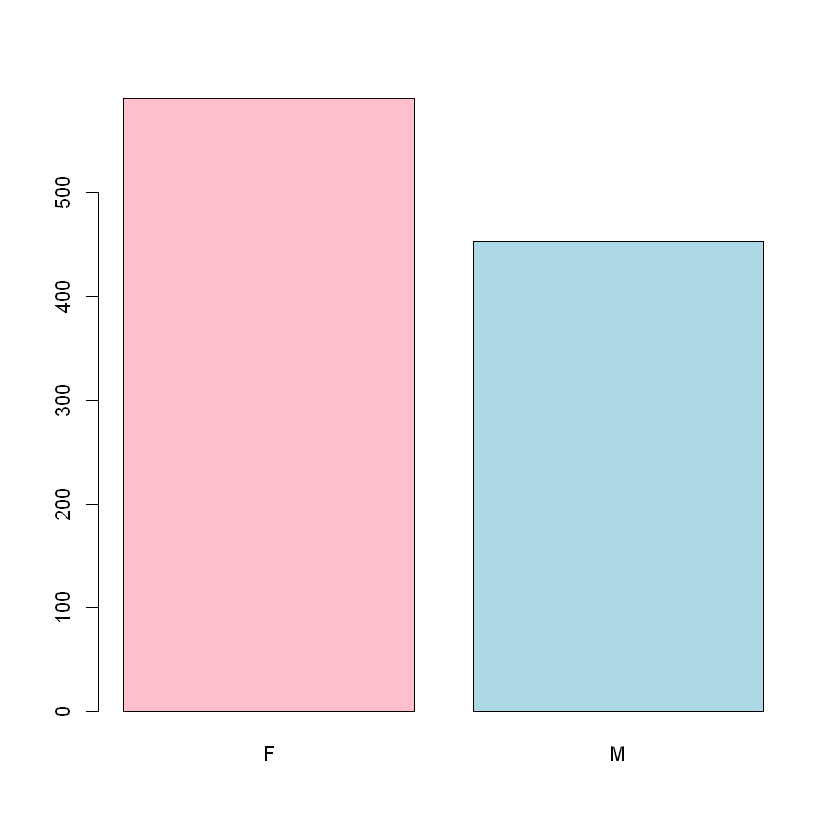

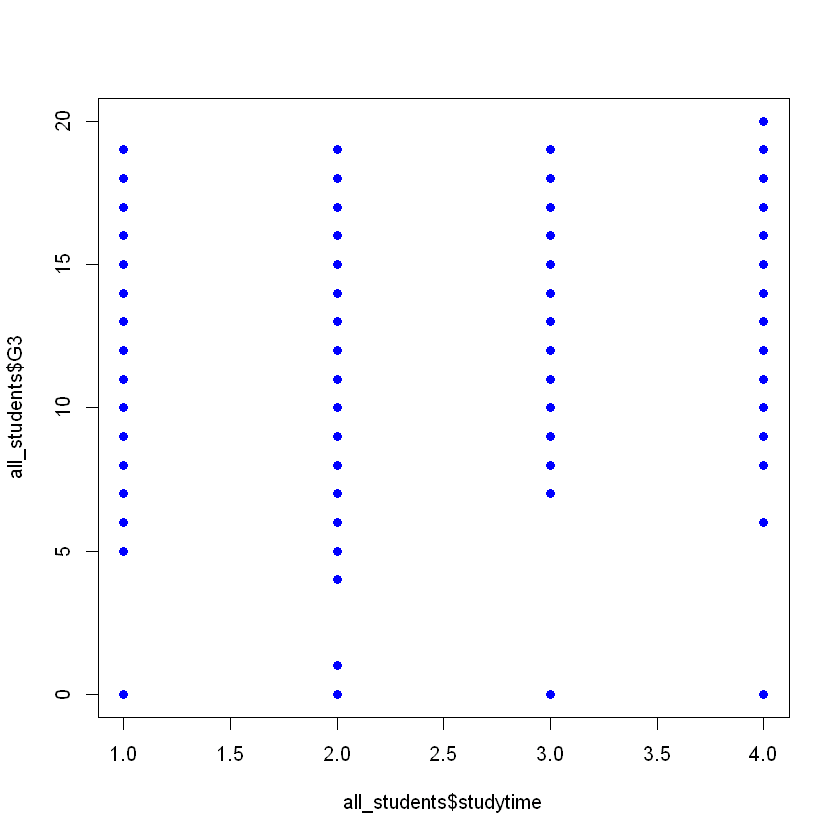

In [4]:
# EDA
hist(all_students$G3, col = "lightblue", main = "Final Grade Distribution")
boxplot(all_students$G3, col = "orange")
barplot(table(all_students$sex), col = c("pink","lightblue"))
plot(all_students$studytime, all_students$G3, col = "blue", pch = 19)

corrplot 0.95 loaded



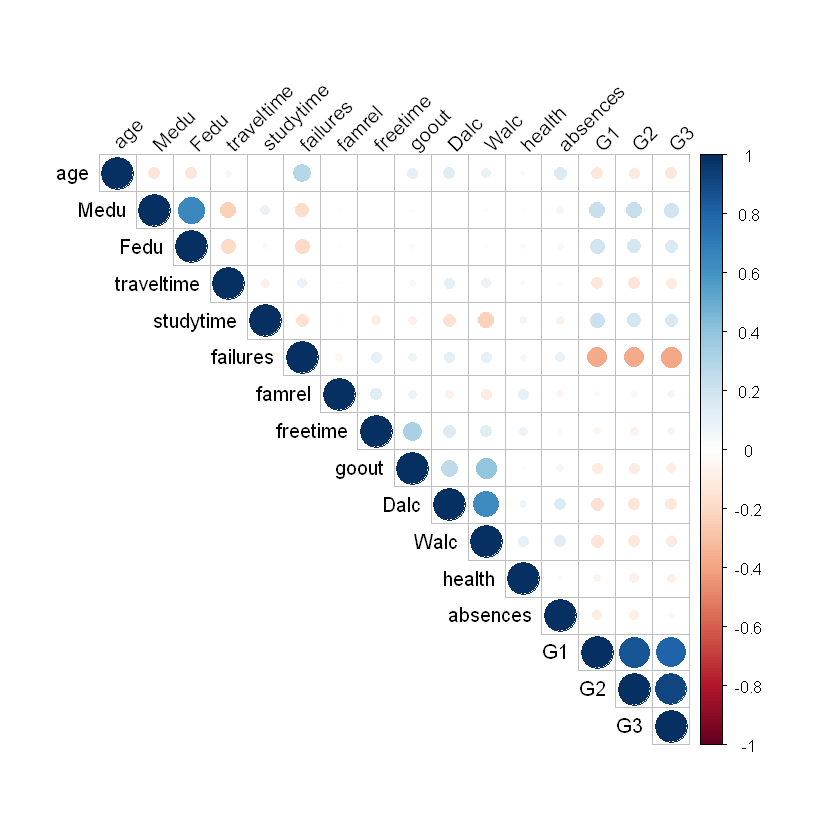

In [5]:
library(corrplot)

# Select ONLY numeric columns for correlation
numeric_df <- all_students %>% select(where(is.numeric))

# Compute correlation - now it will have data!
cor_matrix <- cor(numeric_df, use = "pairwise.complete.obs")

# Plot
corrplot(cor_matrix, method = "circle", type = "upper", tl.col = "black", tl.srt = 45)

In [6]:
# Tag subjects and add features
all_students$subject <- as.factor(all_students$subject)
all_students$total_alc <- all_students$Dalc + all_students$Walc
all_students$parent_edu <- all_students$Medu + all_students$Fedu
all_students$absences_log <- log1p(all_students$absences)

# Keep only relevant predictors (Exclude G3-based pass_fail)
selected_cols <- c("G1", "G2", "studytime", "failures", "absences_log", 
                   "total_alc", "parent_edu", "subject", "higher", "romantic", "G3")

df_final <- all_students[, selected_cols]

set.seed(123)
train_idx <- sample(1:nrow(df_final), 0.8 * nrow(df_final))
train_data <- df_final[train_idx, ]
test_data <- df_final[-train_idx, ]

In [7]:
# Select a broader range of features
selected_cols <- c("G1", "G2", "studytime", "failures", "absences_log", 
                   "total_alc", "parent_edu", "subject", "higher", 
                   "internet", "romantic", "G3")

df_final <- all_students[, selected_cols]

# Create Dummy Variables (One-Hot Encoding)
# This is necessary for both Linear Regression and LightGBM to handle text
df_dummies <- as.data.frame(model.matrix(G3 ~ . -1, data = df_final))
df_dummies$G3 <- df_final$G3

set.seed(123)
train_idx <- sample(1:nrow(df_dummies), 0.8 * nrow(df_dummies))
train_data <- df_dummies[train_idx, ]
test_data <- df_dummies[-train_idx, ]

In [ ]:
# Linear Regression
model_lr <- lm(G3 ~ ., data = train_data)

# Predict
pred_lr <- predict(model_lr, newdata = test_data)

# Performance Metrics
rmse_lr <- sqrt(mean((pred_lr - test_data$G3)^2))
r2_lr <- summary(model_lr)$r.squared
+
cat("Linear Regression RMSE:", round(rmse_lr, 4), "\n")
cat("Linear Regression R2:", round(r2_lr, 4), "\n")

Linear Regression RMSE: 1.3583 
Linear Regression R2: 0.843 


Decision Tree RMSE: 1.4144 
Decision Tree R2: 0.8579 


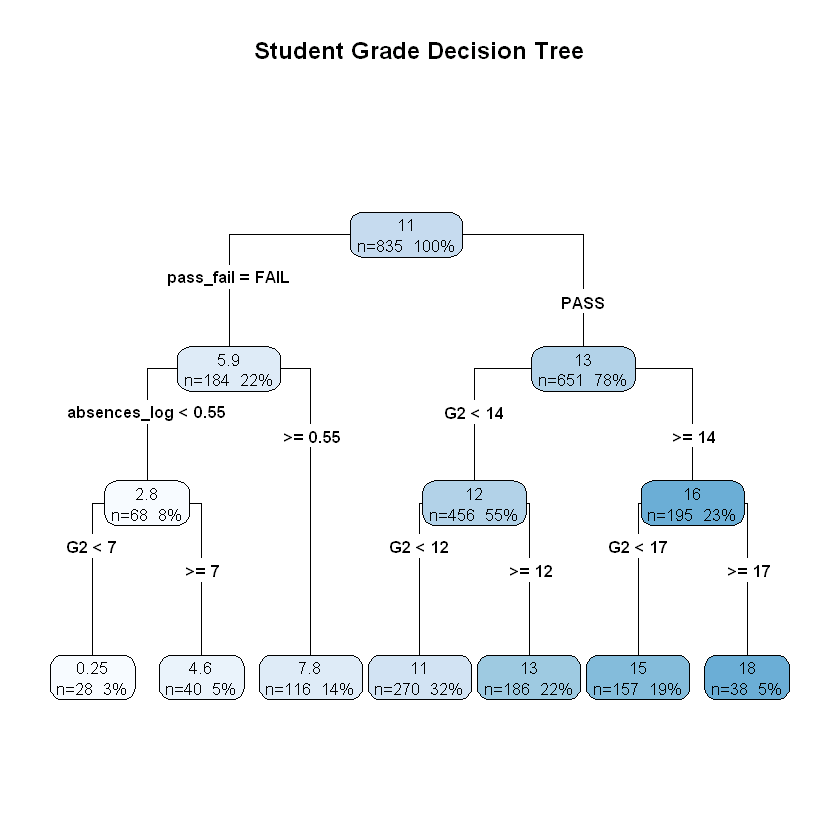

In [23]:
library(rpart)
library(rpart.plot)

# Train Decision Tree
model_dt <- rpart(G3 ~ ., data = train_data, method = "anova")

# Predict and Evaluate
pred_dt <- predict(model_dt, newdata = test_data)
rmse_dt <- sqrt(mean((pred_dt - test_data$G3)^2))
# Calculate R2 for DT
r2_dt <- 1 - sum((test_data$G3 - pred_dt)^2) / sum((test_data$G3 - mean(test_data$G3))^2)

# Plot the tree
rpart.plot(model_dt, main="Student Grade Decision Tree", type=4, extra=101)

cat("Decision Tree RMSE:", round(rmse_dt, 4), "\n")
cat("Decision Tree R2:", round(r2_dt, 4), "\n")

In [ ]:
library(lightgbm)

# Prepare Matrix (Use data.matrix to avoid the 'list' error)
X_train <- data.matrix(train_data[, -which(names(train_data) %in% c("G3", "pass_fail"))])
y_train <- train_data$G3
X_test  <- data.matrix(test_data[, -which(names(test_data) %in% c("G3", "pass_fail"))])
y_test  <- test_data$G3

dtrain <- lgb.Dataset(data = X_train, label = y_train)

params <- list(
  objective = "regression",
  metric = "rmse",
  learning_rate = 0.01,
  num_leaves = 31,
  feature_fraction = 0.8,
  bagging_fraction = 0.7,
  bagging_freq = 5
)

# Train the model
model_lgb <- lgb.train(
  params = params,
  data = dtrain,
  nrounds = 1000,
  valids = list(test = lgb.Dataset(X_test, label = y_test)),
  early_stopping_rounds = 100,
  verbose = -1
)

# Predict and create the missing variables
preds_lgb <- predict(model_lgb, X_test)
rmse_lgb <- sqrt(mean((y_test - preds_lgb)^2))
r2_lgb <- 1 - sum((y_test - preds_lgb)^2) / sum((y_test - mean(y_test))^2)

cat("LightGBM Ready! RMSE:", rmse_lgb, "\n")
print(paste("Improved R2:", round(1 - sum((y_test - preds)^2) / sum((y_test - mean(y_test))^2), 4)))

LightGBM Ready! RMSE: 1.2133 
[1] "Improved R2: 0.8932"


In [11]:
library(randomForest)

# 1. Tuning: Find the best mtry automatically
set.seed(123)
# We use tuneRF to find the mtry that results in the lowest OOB error
tune_result <- tuneRF(
  x = train_data[, -which(names(train_data) == "G3")], 
  y = train_data$G3,
  stepFactor = 1.5,
  improve = 0.01,
  ntreeTry = 500,
  trace = TRUE,
  plot = FALSE
)

best_mtry <- tune_result[which.min(tune_result[,2]), 1]

# 2. Train the Optimized Model
model_rf <- randomForest(
  G3 ~ ., 
  data = train_data,
  ntree = 1000,           # More trees for better stability
  mtry = best_mtry,       # Use the optimized value from tuneRF
  importance = TRUE,
  nodesize = 5            # Smaller nodes allow for more detail
)

# 3. Predict and Evaluate
pred_rf <- predict(model_rf, newdata = test_data)
rmse_rf <- sqrt(mean((pred_rf - test_data$G3)^2))
R2_rf <- 1 - sum((test_data$G3 - pred_rf)^2) / sum((test_data$G3 - mean(test_data$G3))^2)

cat("Optimized RF RMSE:", round(rmse_rf, 4), "\n")
cat("Optimized RF R2:", round(R2_rf, 4), "\n")

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:dplyr':

    combine




mtry = 4  OOB error = 2.335463 
Searching left ...
mtry = 3 	OOB error = 2.496042 
-0.06875699 0.01 
Searching right ...
mtry = 6 	OOB error = 2.202157 
0.05707909 0.01 
mtry = 9 	OOB error = 2.248802 
-0.02118168 0.01 
Optimized RF RMSE: 1.2825 
Optimized RF R2: 0.8831 


In [12]:
# =========================
# FEATURE IMPORTANCE
# =========================

importance(model_rf)


,%IncMSE,IncNodePurity
G1,32.82370455,2941.00837
G2,83.68352089,6907.88890
studytime,3.53715150,179.12520
failures,13.10373028,469.01344
absences_log,59.75215188,813.34167
total_alc,-6.85671166,226.90837
parent_edu,6.26984497,259.11880
subjectmath,13.33420475,95.94909
subjectportuguese,16.96335210,166.11219
higheryes,1.55325050,69.93617


In [14]:
# Add the target labels back for classification
train_data$pass_fail <- as.factor(ifelse(train_data$G3 >= 10, "PASS", "FAIL"))
test_data$pass_fail <- as.factor(ifelse(test_data$G3 >= 10, "PASS", "FAIL"))

# Train the classification model
model_class <- randomForest(
  pass_fail ~ . - G3, # Predict pass_fail using everything EXCEPT the raw grade G3
  data = train_data,
  ntree = 200
)

# Predict and Check Accuracy
pred_class <- predict(model_class, newdata = test_data)
accuracy <- mean(pred_class == test_data$pass_fail)

cat("Classification Accuracy:", round(accuracy * 100, 2), "%\n")

Classification Accuracy: 90.43 %


In [24]:
# Create the comparison dataframe
results <- data.frame(
  Model = c(
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "LightGBM"
  ),
  RMSE = c(
    rmse_lr,   # Ensure you ran the LR cell
    rmse_dt,   # Ensure you ran the DT cell
    rmse_rf,   # Ensure you ran the RF cell
    rmse_lgb   # Created in the step above
  ),
  R2 = c(
    r2_lr,     
    r2_dt,     
    R2_rf,     
    r2_lgb     
  )
)

# Sort the results so the best model (lowest RMSE) is at the top
results <- results[order(results$RMSE), ]

print("--- Final Model Comparison ---")
print(results)

[1] "--- Final Model Comparison ---"


              Model     RMSE        R2
4          LightGBM 1.213300 0.8954044
3     Random Forest 1.282479 0.8831368
1 Linear Regression 1.358288 0.8430490
2     Decision Tree 1.414425 0.8578532


In [27]:
# 1. Create a "Template" with one row from your training data
# This ensures all columns (like subjectportuguese) exist
test_student <- train_data[1, , drop = FALSE]

# 2. Fill it with your "Test Student" values
test_student$G1 <- 12
test_student$G2 <- 14
test_student$studytime <- 3
test_student$failures <- 0
test_student$absences_log <- log1p(2)
test_student$total_alc <- 2
test_student$parent_edu <- 5

# 3. Set the Categorical (Dummy) variables
# Since it's a Math student: set math to 1, others to 0
test_student$subjectmath <- 1
test_student$subjectportuguese <- 0
test_student$higheryes <- 1
test_student$internetyes <- 1
test_student$romanticyes <- 0

# (If your model created 'no' columns as well, set them)
if("higherno" %in% names(test_student)) test_student$higherno <- 0
if("internetno" %in% names(test_student)) test_student$internetno <- 0
if("romanticno" %in% names(test_student)) test_student$romanticno <- 1

# 4. Remove the Target (G3) so the model can predict it
test_student$G3 <- NULL
test_student$pass_fail <- NULL # Remove if it exists

# 5. Predict!
pred_rf <- predict(model_rf, test_student)
pred_lgb <- predict(model_lgb, data.matrix(test_student))

cat("--- Quick Test Result ---\n")
cat("Random Forest Grade:", round(pred_rf, 2), "\n")
cat("LightGBM Grade:     ", round(pred_lgb, 2), "\n")
cat("Final Status:       ", ifelse(pred_rf >= 10, "PASS", "FAIL"), "\n")

--- Quick Test Result ---
Random Forest Grade: 14.23 
LightGBM Grade:      14.14 
Final Status:        PASS 


In [28]:
# =========================
# SAVE TRAINED MODELS
# =========================

# Save Random Forest model
saveRDS(model_rf, "model_rf.rds")

# Save Linear Regression model
saveRDS(model_lr, "model_lr.rds")

# Save Decision Tree model
saveRDS(model_dt, "model_dt.rds")

# Save LightGBM model
saveRDS(model_lgb, "model_lgb.rds")

print("All models saved successfully!")

[1] "All models saved successfully!"
